<a href="https://colab.research.google.com/github/niran-j2005/assesment/blob/main/niranjan_HR_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing the training data and modules

In [1]:
# importing the modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For training data

In [2]:
# importing the training data

tra_file = '/content/train_LZdllcl.csv'
df_train = pd.read_csv(tra_file)
df_train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


# Explotary Data Analysis

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [4]:
df_train.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score', 'is_promoted'],
      dtype='object')

In [5]:
df_train.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [6]:
df_train.shape

(54808, 14)

In [7]:
df_train.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [8]:
df_train.duplicated().sum()

np.int64(0)

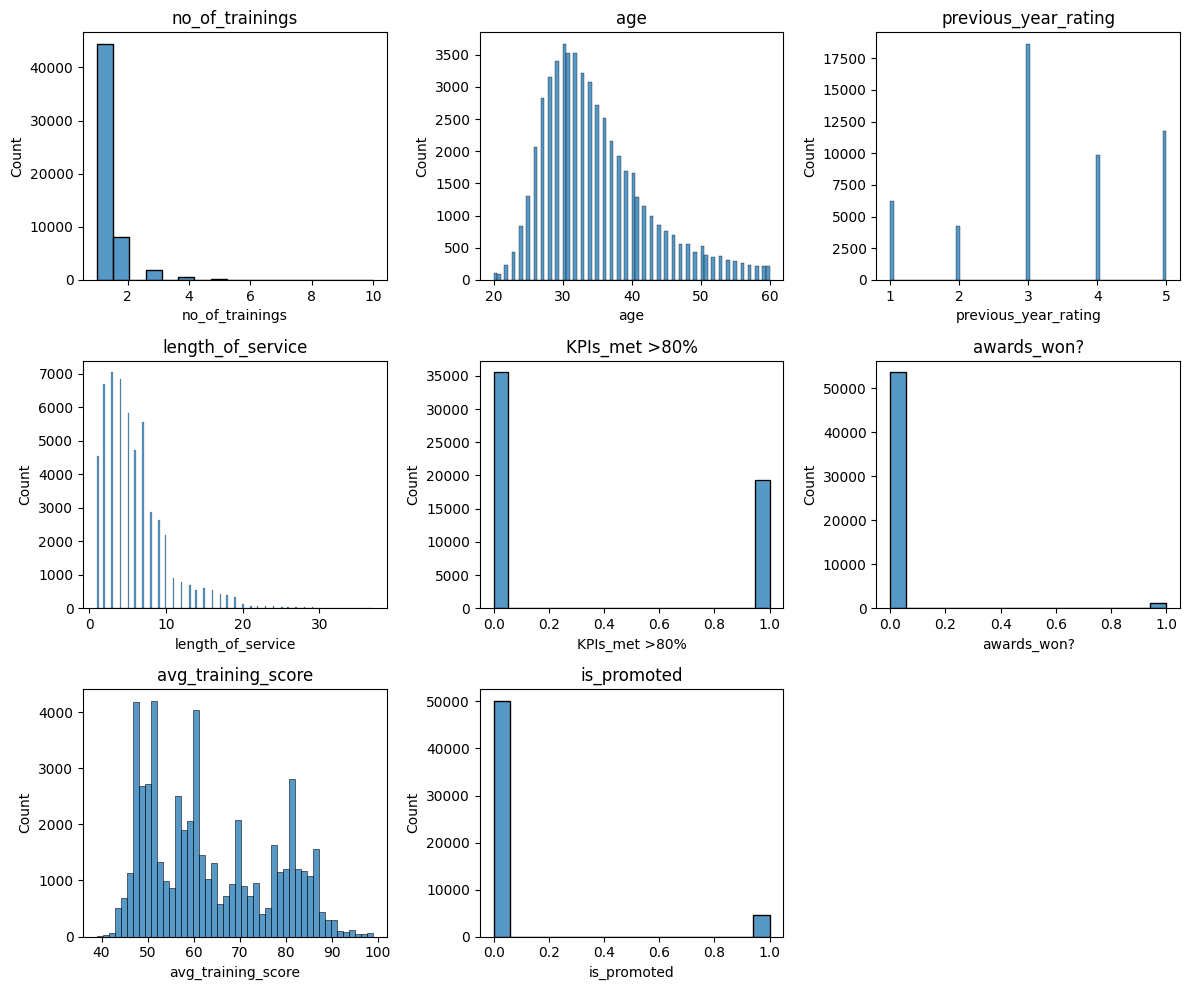

In [9]:
# drawing the histplot for numerical values

num_value_columns = ['no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score', 'is_promoted']

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_value_columns):
    sns.histplot(data=df_train, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(num_value_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Data Preprocessing

Filling the missing values

In [10]:
# for education columns
df_train['education'].value_counts()

,count
education,
Bachelor's,36669
Master's & above,14925
Below Secondary,805


In [11]:
df_train['education'].isna().sum()

np.int64(2409)

In [12]:
# for previous year ratings
df_train['previous_year_rating'].value_counts()

,count
previous_year_rating,
3.0,18618
5.0,11741
4.0,9877
1.0,6223
2.0,4225


In [13]:
df_train['previous_year_rating'].isna().sum()

np.int64(4124)

In [14]:
# since both are a categorical value filling them with mode of each

fill_col = ['education','previous_year_rating']

for col in fill_col:
  df_train[col] = df_train[col].fillna(df_train[col].mode()[0])


In [15]:
df_train.isna().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


In [16]:
df_train.shape

(54808, 14)

Checking the outliers

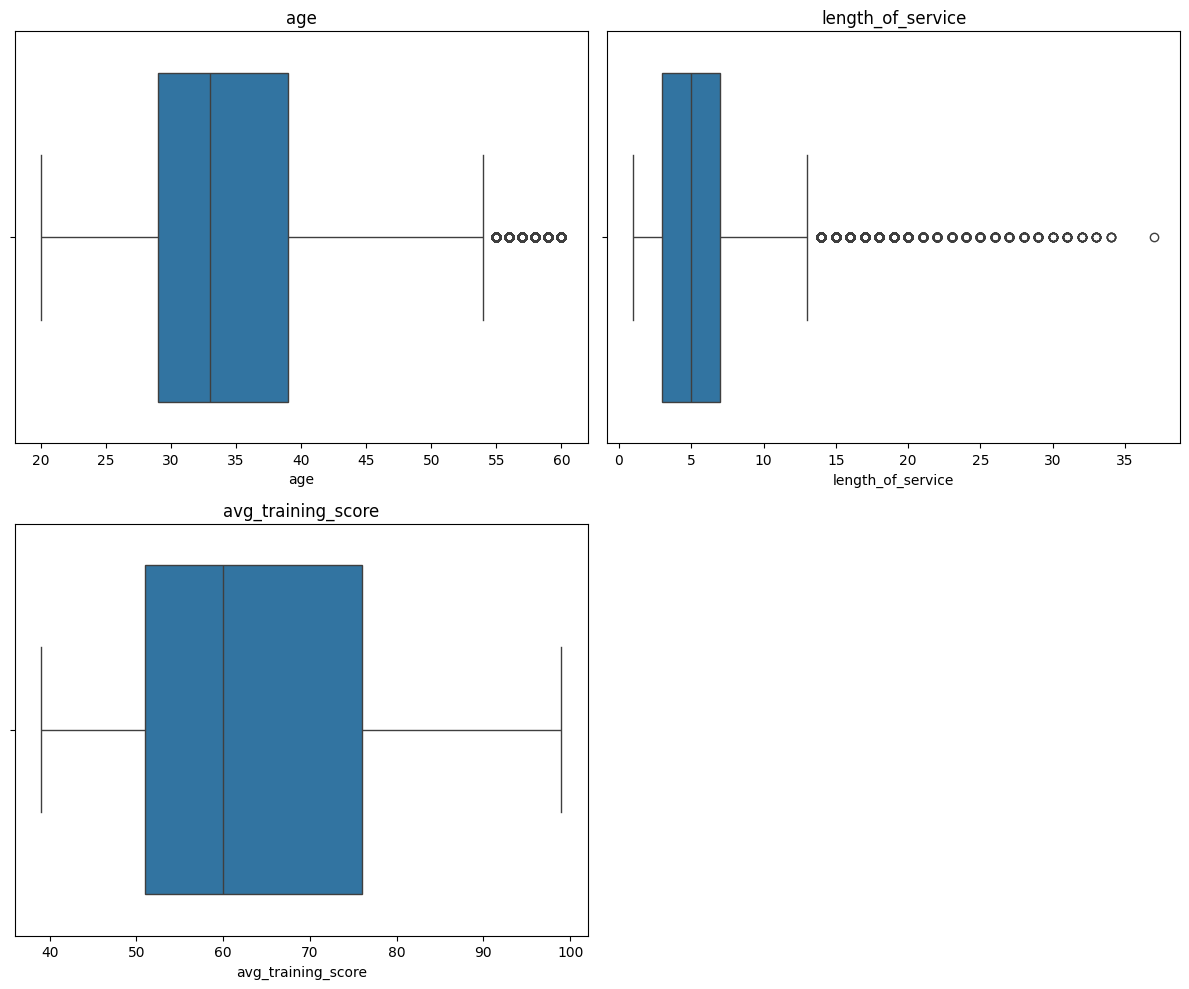

In [17]:
# drawing the histplot for numerical values

num_value_columns = ['age',
       'length_of_service','avg_training_score']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_value_columns):
    sns.boxplot(data=df_train, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(num_value_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

age (20 to 60): The IQR upper cutoff is 54, but employees aged 55 to 60 are simply senior staff approaching typical retirement age.    length_of_service (1 to 37): The cutoff is 13 years, but 14 to 37 years represents long-tenured employees.   In every case, length_of_service < age, confirming these records are legitimate.  no_of_trainings (1 to 10): The formula flags anything $> 1$ because roughly 81% of staff took only 1 training session, making a mathematical threshold of 1.0 inappropriate for count data.

# Encoding

In [18]:
df_train['department'].value_counts()

,count
department,
Sales & Marketing,16840
Operations,11348
Technology,7138
Procurement,7138
Analytics,5352
Finance,2536
HR,2418
Legal,1039
R&D,999


In [19]:
df_train['region'].value_counts()

,count
region,
region_2,12343
region_22,6428
region_7,4843
region_15,2808
region_13,2648
region_26,2260
region_31,1935
region_4,1703
region_27,1659


In [20]:
df_train['education'].value_counts()

,count
education,
Bachelor's,39078
Master's & above,14925
Below Secondary,805


In [21]:
df_train['gender'].value_counts()

,count
gender,
m,38496
f,16312


In [22]:
df_train['recruitment_channel'].value_counts()

,count
recruitment_channel,
other,30446
sourcing,23220
referred,1142


In [23]:
# Categorical Encoding
categorical_cols = [
    "department",
    "region",
    "education",
    "gender",
    "recruitment_channel",
]

# One-Hot Encoding fitted on train and reindexed to match test exactly
df_train = pd.get_dummies(
    df_train, columns=categorical_cols, drop_first=True, dtype=int
)

In [24]:
df_train

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted,department_Finance,...,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing
0,65438,1,35,5.0,8,1,0,49,0,0,...,0,0,1,0,0,0,1,0,0,1
1,65141,1,30,5.0,4,0,0,60,0,0,...,0,0,0,0,0,0,0,1,0,0
2,7513,1,34,3.0,7,0,0,50,0,0,...,0,0,0,0,0,0,0,1,0,1
3,2542,2,39,1.0,10,0,0,50,0,0,...,0,0,0,0,0,0,0,1,0,0
4,48945,1,45,3.0,2,0,0,73,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54803,3030,1,48,3.0,17,0,0,78,0,0,...,0,0,0,0,0,0,0,1,0,1
54804,74592,1,37,2.0,6,0,0,56,0,0,...,0,0,0,0,0,0,1,0,0,0
54805,13918,1,27,5.0,3,1,0,79,0,0,...,0,0,0,0,0,0,0,1,0,0
54806,13614,1,29,1.0,2,0,0,45,0,0,...,0,0,0,0,1,0,0,1,0,1


# Scaling

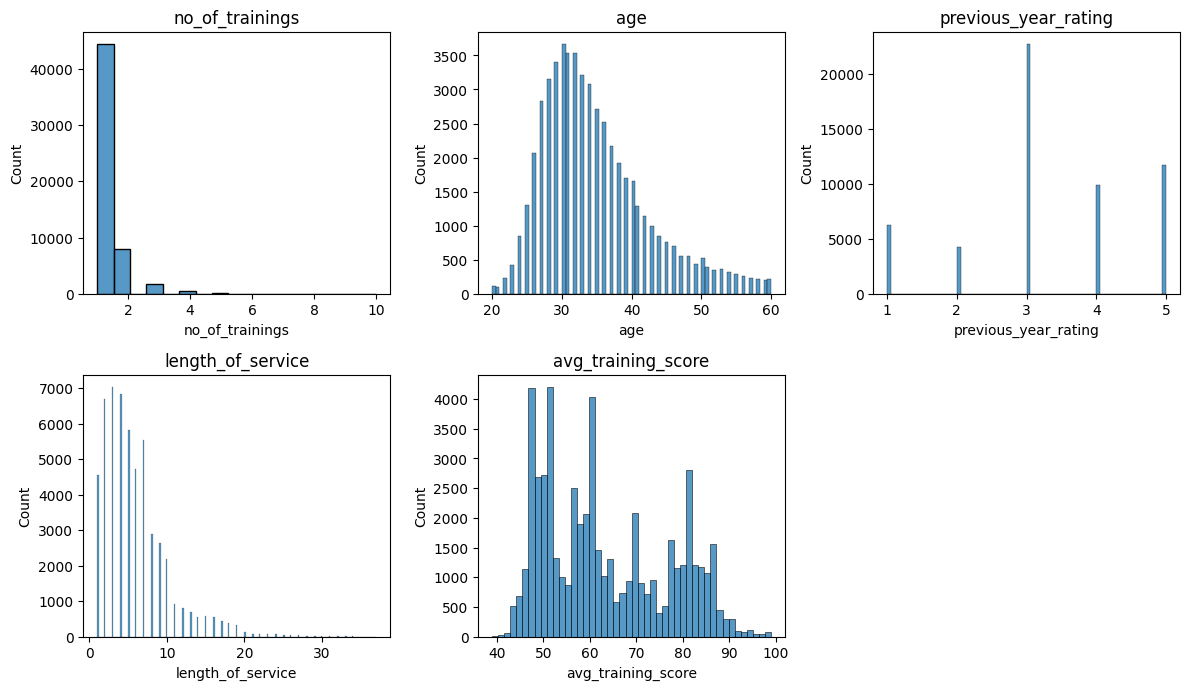

In [25]:
# drawing the histplot for numerical values

num_value_columns = ['no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service','avg_training_score',]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_value_columns):
    sns.histplot(data=df_train, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(num_value_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [26]:
from sklearn.preprocessing import MinMaxScaler

# Identify numerical continuous columns
min_max_cols = ['age','avg_training_score']

# Initialize scaler
min_max_scaler = MinMaxScaler()
df_train[min_max_cols] = min_max_scaler.fit_transform(df_train[min_max_cols])

In [27]:
from sklearn.preprocessing import StandardScaler

# Identify numerical continuous columns
std_cols = [ 'length_of_service', 'no_of_trainings', 'previous_year_rating']

# Initialize scaler
std_scaler = StandardScaler()
df_train[std_cols] = std_scaler.fit_transform(df_train[std_cols])

In [28]:
df_train

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted,department_Finance,...,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing
0,65438,-0.415276,0.375,1.395766,0.500460,1,0,0.166667,0,0,...,0,0,1,0,0,0,1,0,0,1
1,65141,-0.415276,0.250,1.395766,-0.437395,0,0,0.350000,0,0,...,0,0,0,0,0,0,0,1,0,0
2,7513,-0.415276,0.350,-0.250651,0.265996,0,0,0.183333,0,0,...,0,0,0,0,0,0,0,1,0,1
3,2542,1.226063,0.475,-1.897069,0.969387,0,0,0.183333,0,0,...,0,0,0,0,0,0,0,1,0,0
4,48945,-0.415276,0.625,-0.250651,-0.906322,0,0,0.566667,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54803,3030,-0.415276,0.700,-0.250651,2.610632,0,0,0.650000,0,0,...,0,0,0,0,0,0,0,1,0,1
54804,74592,-0.415276,0.425,-1.073860,0.031532,0,0,0.283333,0,0,...,0,0,0,0,0,0,1,0,0,0
54805,13918,-0.415276,0.175,1.395766,-0.671858,1,0,0.666667,0,0,...,0,0,0,0,0,0,0,1,0,0
54806,13614,-0.415276,0.225,-1.897069,-0.906322,0,0,0.100000,0,0,...,0,0,0,0,1,0,0,1,0,1


#Data Splitting

In [29]:
# splitting x and y train from training data

y_train = df_train['is_promoted']
x_train  =df_train.drop(columns=['employee_id','is_promoted'])

In [30]:
x_train

,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,department_Finance,department_HR,department_Legal,...,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing
0,-0.415276,0.375,1.395766,0.500460,1,0,0.166667,0,0,0,...,0,0,1,0,0,0,1,0,0,1
1,-0.415276,0.250,1.395766,-0.437395,0,0,0.350000,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,-0.415276,0.350,-0.250651,0.265996,0,0,0.183333,0,0,0,...,0,0,0,0,0,0,0,1,0,1
3,1.226063,0.475,-1.897069,0.969387,0,0,0.183333,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,-0.415276,0.625,-0.250651,-0.906322,0,0,0.566667,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54803,-0.415276,0.700,-0.250651,2.610632,0,0,0.650000,0,0,0,...,0,0,0,0,0,0,0,1,0,1
54804,-0.415276,0.425,-1.073860,0.031532,0,0,0.283333,0,0,0,...,0,0,0,0,0,0,1,0,0,0
54805,-0.415276,0.175,1.395766,-0.671858,1,0,0.666667,0,0,0,...,0,0,0,0,0,0,0,1,0,0
54806,-0.415276,0.225,-1.897069,-0.906322,0,0,0.100000,0,0,0,...,0,0,0,0,1,0,0,1,0,1


# For testing data

In [33]:
# importing the text file

test_file = '/content/test_2umaH9m.csv'
df_test = pd.read_csv(test_file)
df_test.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [34]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           23490 non-null  int64  
 1   department            23490 non-null  object 
 2   region                23490 non-null  object 
 3   education             22456 non-null  object 
 4   gender                23490 non-null  object 
 5   recruitment_channel   23490 non-null  object 
 6   no_of_trainings       23490 non-null  int64  
 7   age                   23490 non-null  int64  
 8   previous_year_rating  21678 non-null  float64
 9   length_of_service     23490 non-null  int64  
 10  KPIs_met >80%         23490 non-null  int64  
 11  awards_won?           23490 non-null  int64  
 12  avg_training_score    23490 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 2.3+ MB


In [35]:
df_test.shape

(23490, 13)

In [36]:
df_test.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
count,23490.000000,23490.000000,23490.000000,21678.000000,23490.000000,23490.000000,23490.000000,23490.000000
mean,39041.399149,1.254236,34.782929,3.339146,5.810387,0.358834,0.022776,63.263133
std,22640.809201,0.600910,7.679492,1.263294,4.207917,0.479668,0.149191,13.411750
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19370.250000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,38963.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58690.000000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


In [37]:
df_test.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score'],
      dtype='object')

In [38]:
df_test.isnull().sum()

,0
employee_id,0
department,0
region,0
education,1034
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,1812
length_of_service,0


In [39]:
df_test.duplicated().sum()

np.int64(0)

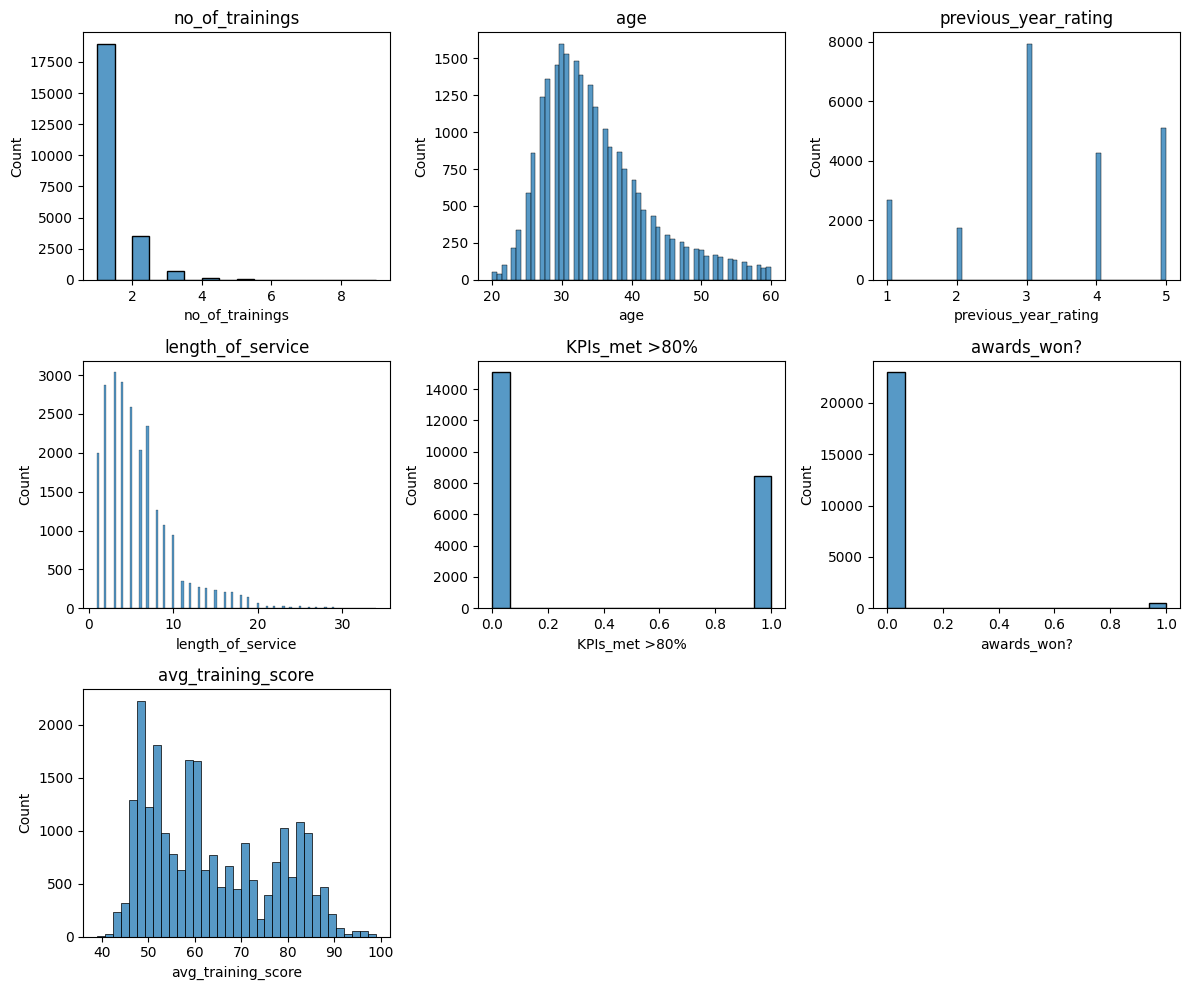

In [40]:
# drawing the histplot for numerical values

num_value_columns = ['no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score']

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_value_columns):
    sns.histplot(data=df_test, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(num_value_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Data Preprocessing

Filling the missing values

In [41]:
# for education columns
df_test['education'].value_counts()

,count
education,
Bachelor's,15578
Master's & above,6504
Below Secondary,374


In [42]:
df_test['education'].isna().sum()

np.int64(1034)

In [43]:
# for previous year ratings
df_test['previous_year_rating'].value_counts()

,count
previous_year_rating,
3.0,7921
5.0,5097
4.0,4249
1.0,2680
2.0,1731


In [44]:
df_test['previous_year_rating'].isna().sum()

np.int64(1812)

In [45]:
# since both are a categorical value filling them with mode of each

fill_col = ['education','previous_year_rating']

for col in fill_col:
  df_test[col] = df_test[col].fillna(df_test[col].mode()[0])


In [46]:
df_test.isna().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


Checking for outliers

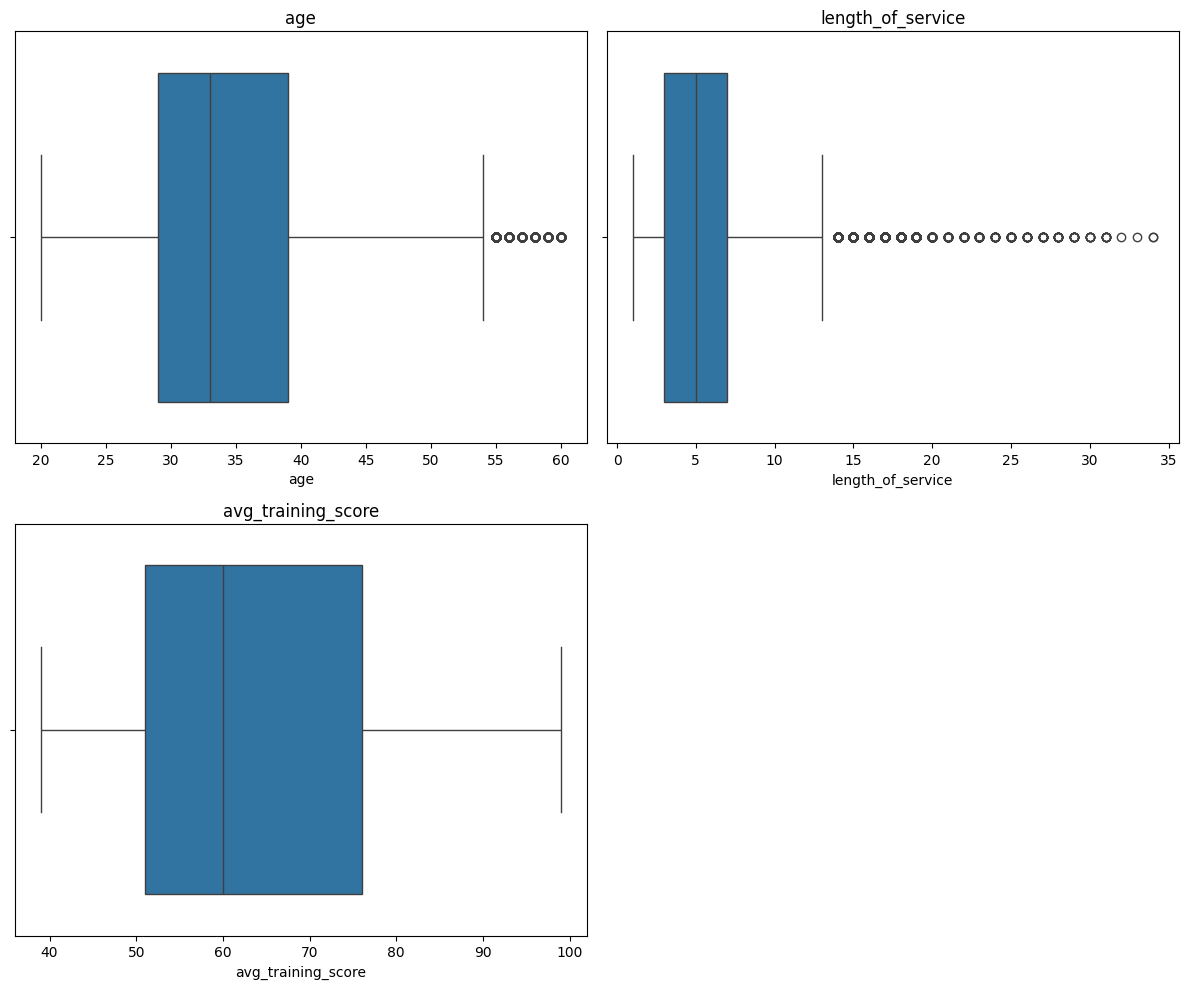

In [47]:
# drawing the histplot for numerical values

num_value_columns = ['age',
       'length_of_service','avg_training_score']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_value_columns):
    sns.boxplot(data=df_test, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(num_value_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


age (20 to 60): The IQR upper cutoff is 54, but employees aged 55 to 60 are simply senior staff approaching typical retirement age. length_of_service (1 to 37): The cutoff is 13 years, but 14 to 37 years represents long-tenured employees. In every case, length_of_service < age, confirming these records are legitimate. no_of_trainings (1 to 10): The formula flags anything  >1  because roughly 81% of staff took only 1 training session, making a mathematical threshold of 1.0 inappropriate for count data.

# Encoding

In [48]:
df_test['department'].value_counts()

,count
department,
Sales & Marketing,7315
Operations,4764
Procurement,3020
Technology,3011
Analytics,2319
Finance,1091
HR,1085
Legal,445
R&D,440


In [49]:
df_test['region'].value_counts()

,count
region,
region_2,5299
region_22,2739
region_7,1982
region_13,1167
region_15,1130
region_26,1011
region_31,844
region_4,775
region_27,710


In [50]:
df_test['education'].value_counts()

,count
education,
Bachelor's,16612
Master's & above,6504
Below Secondary,374


In [51]:
df_test['recruitment_channel'].value_counts()

,count
recruitment_channel,
other,13078
sourcing,9961
referred,451


In [52]:
# Categorical Encoding
categorical_cols = [
    "department",
    "region",
    "education",
    "gender",
    "recruitment_channel",
]

# One-Hot Encoding fitted on train and reindexed to match test exactly
df_test = pd.get_dummies(
    df_test, columns=categorical_cols, drop_first=True, dtype=int
)

# Scaling

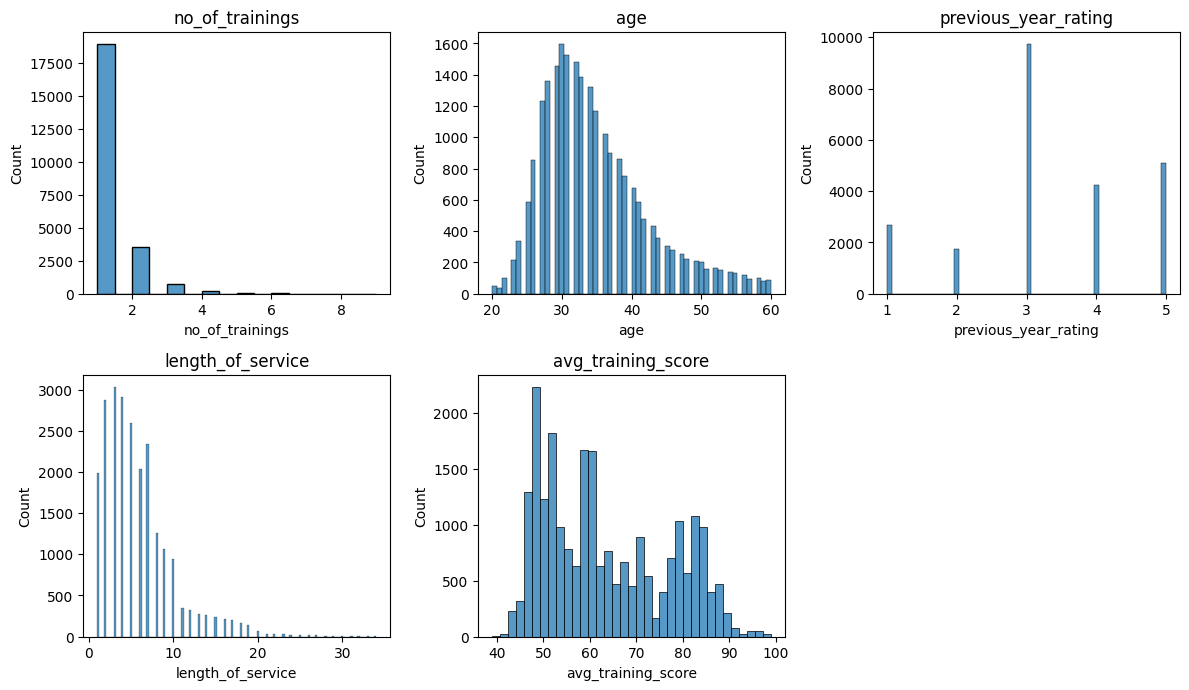

In [53]:
# drawing the histplot for numerical values

num_value_columns = ['no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service','avg_training_score',]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_value_columns):
    sns.histplot(data=df_test, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(num_value_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [54]:
from sklearn.preprocessing import MinMaxScaler

# Identify numerical continuous columns
min_max_cols = ['age','avg_training_score']

df_test[min_max_cols] = min_max_scaler.transform(df_test[min_max_cols])

In [55]:
from sklearn.preprocessing import StandardScaler

# Identify numerical continuous columns
std_cols = [ 'length_of_service', 'no_of_trainings', 'previous_year_rating']

df_test[std_cols] = std_scaler.transform(df_test[std_cols])

In [56]:
# splitting x and y train from training data
x_test  =df_test.drop(columns=['employee_id'])

In [57]:
x_test

,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,department_Finance,department_HR,department_Legal,...,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing
0,-0.415276,0.100,-0.250651,-1.140785,1,0,0.633333,0,0,0,...,0,0,0,0,0,0,0,1,0,1
1,-0.415276,0.275,-0.250651,-0.202931,0,0,0.200000,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,-0.415276,0.275,-1.897069,-0.437395,0,0,0.133333,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2.867403,0.275,-1.073860,0.734923,0,0,0.433333,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-0.415276,0.250,0.572557,0.265996,0,0,0.366667,1,0,0,...,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23485,-0.415276,0.100,-0.250651,-1.140785,0,0,0.366667,0,0,1,...,0,0,0,0,0,1,0,1,0,1
23486,-0.415276,0.275,-0.250651,0.265996,0,0,0.583333,0,0,0,...,0,0,0,0,0,0,0,1,0,1
23487,-0.415276,0.150,0.572557,-0.437395,0,0,0.183333,0,1,0,...,0,0,0,0,0,0,0,0,0,1
23488,2.867403,0.175,-0.250651,-1.140785,0,0,0.516667,0,0,0,...,0,0,0,0,0,0,0,1,0,1


In [58]:
# Align columns
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

#Dimensionaliity Reduction Using PCA

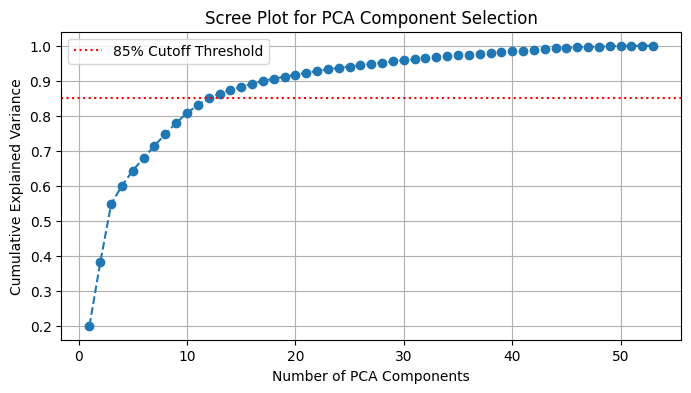

In [59]:
# Checking how many components is needed using graph

from sklearn.decomposition import PCA

# Fit PCA on all components
pca_full = PCA().fit(x_train)
cum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot Cumulative Explained Variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_variance) + 1), cum_variance, marker='o', linestyle='--')
plt.axhline(y=0.85, color='r', linestyle=':', label='85% Cutoff Threshold')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot for PCA Component Selection')
plt.grid(True)
plt.legend()
plt.show()

In [60]:
# Generate column names based on the number of components
pca_cols = [f'PC{i+1}' for i in range(x_train.shape[1])]

# Apply PCA properly
pca = PCA(n_components=7, random_state=42)
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

pca_cols = [f'PC{i+1}' for i in range(x_train.shape[1])]
x_train = pd.DataFrame(data=x_train, columns=pca_cols)
x_test = pd.DataFrame(data=x_test, columns=pca_cols)

print("Train PCA shape:", x_train.shape)
print("Test PCA shape:", x_test.shape)

Train PCA shape: (54808, 7)
Test PCA shape: (23490, 7)


In [61]:
# Apply PCA properly
pca = PCA(n_components=7, random_state=42)
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

pca_cols = [f'PC{i+1}' for i in range(x_train.shape[1])]
x_train = pd.DataFrame(data=x_train, columns=pca_cols)
x_test = pd.DataFrame(data=x_test, columns=pca_cols)

print("Train PCA shape:", x_train.shape)
print("Test PCA shape:", x_test.shape)

Train PCA shape: (54808, 7)
Test PCA shape: (23490, 7)


# Train - Test - Split

In [62]:
# Split training set to test models legitimately

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Finding the optimal F1-Score

In [63]:
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier

model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.08,
    max_leaf_nodes=31,
    random_state=42
)

# 5-Fold CV to find the optimal decision threshold for F1-Score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_probs = cross_val_predict(model, x_train, y_train, cv=cv, method="predict_proba")[:, 1]

best_th = 0.5
best_f1 = 0
for th in np.arange(0.20, 0.50, 0.02):
    score = f1_score(y_train, (oof_probs >= th).astype(int))
    if score > best_f1:
        best_f1 = score
        best_th = th

print(f"Optimal Threshold: {best_th:.2f} -> CV Binary F1-Score: {best_f1:.4f}")

Optimal Threshold: 0.20 -> CV Binary F1-Score: 0.2720


#  Checking the model

In [64]:
# checking using the Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score



rfc = RandomForestClassifier(n_estimators = 6, random_state = 42)
rfc.fit(x_train,y_train)
y_pred_rfc = rfc.predict(x_test)

print('Accuracy Score:',accuracy_score(y_test,y_pred_rfc))
print('Confusion Matrix:',confusion_matrix(y_test,y_pred_rfc))
score = f1_score(y_test, y_pred_rfc)
print(f"F1-Score: {score:.4f}")

Accuracy Score: 0.9066776135741653
Confusion Matrix: [[9869  159]
 [ 864   70]]
F1-Score: 0.1204


In [65]:
# checking using the logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,f1_score

lg = LogisticRegression(class_weight = 'balanced', random_state = 42, max_iter=1000)
lg.fit(x_train,y_train)
y_pred_lg = lg.predict(x_test)

print('Accuracy Score:',accuracy_score(y_test,y_pred_lg))
print('Confusion Matrix:',confusion_matrix(y_test,y_pred_lg))
score = f1_score(y_test, y_pred_lg)
print(f"F1-Score: {score:.4f}")

Accuracy Score: 0.6693121693121693
Confusion Matrix: [[6688 3340]
 [ 285  649]]
F1-Score: 0.2637


In [66]:
# checking by xg classifier

from xgboost import XGBClassifier

scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)  # approx. 10.7
xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=4,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
score = f1_score(y_test, y_pred_xgb)
print(f"F1-Score: {score:.4f}")

Accuracy: 0.6637474913336983
Confusion Matrix:
 [[6567 3461]
 [ 225  709]]
F1-Score: 0.2778


Checking the best paramas

In [67]:
# for random forest
RandomForestClassifier().get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [68]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [10, 20, 30,],
    'max_depth': [None, 5, 10, 25],
    'min_samples_split': [2, 15],
    'min_samples_leaf': [1, 4, 6],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

random_search_rfc = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions = param_dist,n_iter=20,cv = 5,
    n_jobs = -1,verbose=1,random_state=42
)

random_search_rfc.fit(x_train,y_train)
best_rf_model = random_search_rfc.best_estimator_
print(best_rf_model)
print('Best Params:', random_search_rfc.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RandomForestClassifier(max_depth=10, max_features='log2', min_samples_leaf=4,
                       min_samples_split=15, n_estimators=20, random_state=42)
Best Params: {'n_estimators': 20, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'gini'}


In [69]:
# checking using the Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

rfc = RandomForestClassifier(n_estimators = 1, random_state = 42)
rfc.fit(x_train,y_train)
y_pred_rfc = rfc.predict(x_test)

print('Accuracy Score:',accuracy_score(y_test,y_pred_rfc))
print('Confusion Matrix:',confusion_matrix(y_test,y_pred_rfc))
score = f1_score(y_test, y_pred_rfc)
print(f"F1-Score: {score:.4f}")

Accuracy Score: 0.8585112205801861
Confusion Matrix: [[9227  801]
 [ 750  184]]
F1-Score: 0.1918


In [70]:
# for xgb model
xgb_model.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': True,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.08,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 4,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 150,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': 10.742367434386717,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [71]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [None, 5, 10, 15, 20, 25,4],
    'max_leaves': [1, 2, 3, 4, 6],
    'learning_rate': [0.1,0.3,0.4,0.08]
}

random_search_xgbmodel = RandomizedSearchCV(
    estimator = XGBClassifier(random_state=42),
    param_distributions = param_dist,n_iter=20,
    cv=5, n_jobs=-1, verbose = 1, random_state = 42
)

random_search_xgbmodel.fit(x_train,y_train)
best_xgb_model = random_search_xgbmodel.best_estimator_
print(best_xgb_model)
print('Best Params:', random_search_xgbmodel.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.08, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=4, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
Best Params: {'max_leaves': 4, 'max_depth': None, 'learning_rate': 0.08}


In [72]:
# checking by xg classifier

scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)  # approx. 10.7
xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=4,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
score = f1_score(y_test, y_pred_xgb)
print(f"F1-Score: {score:.4f}")

xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
score = f1_score(y_test, y_pred_xgb)
print(f"F1-Score: {score:.4f}")

Accuracy: 0.6637474913336983
Confusion Matrix:
 [[6567 3461]
 [ 225  709]]
F1-Score: 0.2778
Accuracy: 0.6637474913336983
Confusion Matrix:
 [[6567 3461]
 [ 225  709]]
F1-Score: 0.2778


In [73]:
# for logistic regression
LogisticRegression().get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [74]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    # Express class weights as dictionaries or 'balanced'
    'class_weight': [None, 'balanced', {0: 1, 1: 3.35}, {0: 1, 1: 5}],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],               # Regularization strength
    'solver': ['liblinear', 'lbfgs'],                   # Optimization algorithms
    'intercept_scaling': [1, 3, 5, 7],
    'tol': [1e-4, 2e-4, 3e-4]
}

random_search = RandomizedSearchCV(estimator=LogisticRegression(random_state=42),
                                    param_distributions=param_dist,n_iter=20,cv=5,n_jobs=-1,
                                    verbose=1,random_state=42)
random_search.fit(x_train, y_train)

best_rf_model_rs = random_search.best_estimator_
print(best_rf_model_rs)
print('Best Params:', random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
LogisticRegression(C=0.01, intercept_scaling=7, random_state=42, tol=0.0002)
Best Params: {'tol': 0.0002, 'solver': 'lbfgs', 'intercept_scaling': 7, 'class_weight': None, 'C': 0.01}


In [75]:
# checking using the logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

lg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000,
                        intercept_scaling=7,tol = 0.0002, solver='lbfgs')
lg.fit(x_train,y_train)
y_pred_lg = lg.predict(x_test)

print('Accuracy Score:',accuracy_score(y_test,y_pred_lg))
print('Confusion Matrix:',confusion_matrix(y_test,y_pred_lg))
score = f1_score(y_test, y_pred_lg)
print(f"F1-Score: {score:.4f}")

Accuracy Score: 0.6693121693121693
Confusion Matrix: [[6688 3340]
 [ 285  649]]
F1-Score: 0.2637


Creating the Submission File

In [78]:
# 1. Load submission
sub = pd.read_csv('/content/sample_submission_M0L0uXE.csv')

# 2. Extract original test features from preprocessed test DataFrame
x_test = df_test.drop(columns=['employee_id'])

# To fix the ValueError, we must reconstruct the PCA using the original training columns
from sklearn.decomposition import PCA
x_train_original = df_train.drop(columns=['employee_id', 'is_promoted'])

# Align columns with test set just like in preprocessing
x_train_original, x_test = x_train_original.align(x_test, join='left', axis=1, fill_value=0)

# Re-initialize and refit PCA properly on original training data
pca_correct = PCA(n_components=7, random_state=42)
pca_correct.fit(x_train_original)

# 3. Project the test features into PCA space using the correct transformer
x_test_transformed = pca_correct.transform(x_test)
pca_cols = [f'PC{i+1}' for i in range(7)]
x_test_df = pd.DataFrame(data=x_test_transformed, columns=pca_cols)

# 4. Predict class probabilities on the actual test features
test_probabilities = lg.predict_proba(x_test_df)[:, 1]

# 5. Apply the optimal threshold to get binary 0/1 predictions
optimal_threshold = 0.290
test_predictions = (test_probabilities >= optimal_threshold).astype(int)

# 6. Replace the target column with your model's predictions
sub['is_promoted'] = test_predictions

# Confirm row count matches (23,490)
print("Submission shape:", sub.shape)
print(sub.head())

Submission shape: (23490, 2)
   employee_id  is_promoted
0         8724            1
1        74430            0
2        72255            0
3        38562            0
4        64486            1


In [80]:
# 1. Verify row count matches the test dataset exactly (23,490 rows)
assert len(sub) == 23490, f"Expected 23,490 rows, got {len(sub)}"

# 2. Confirm no null or NaN values exist
assert sub['is_promoted'].isnull().sum() == 0, "Missing values detected!"

# 3. Check predicted class distribution
print(sub['is_promoted'].value_counts())




is_promoted
1    16802
0     6688
Name: count, dtype: int64
